# Ingesta, Preprocesamiento, EDA y Baseline

El mapeo tradicional de zonas de interés aurífero mediante **isovalores de Au** es univariable: solo delimita zonas donde el Au medido es alto, produciendo áreas pequeñas y **omitiendo "zonas ciegas"** — lugares donde el Au superficial es bajo pero cuya **firma geoquímica multi-elemento** (pathfinders como As, Sb, etc.) se parece a la de las zonas mineralizadas.

Este proyecto propone un **clasificador de Machine Learning multivariable** que aprende la firma geoquímica completa para identificar zonas de interés que el mapeo de isovalores dejaría fuera. Se trabaja con **datos históricos**: el modelo debe exprimir al máximo la información disponible.

## Configuración

In [1]:
import warnings, os, json, platform
from datetime import datetime
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.spatial import cKDTree

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier)
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_curve)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

OUT = 'outputs_sprint0'
DIR_DATA, DIR_MODELS, DIR_FIG, DIR_TAB = f'{OUT}/data', f'{OUT}/models', f'{OUT}/figures', f'{OUT}/tables'
for d in (OUT, DIR_DATA, DIR_MODELS, DIR_FIG, DIR_TAB):
    os.makedirs(d, exist_ok=True)

MODEL_COLORS = {
    'KNN': 'blue', 'Reg. Logística': 'orange', 'SVM (RBF)': 'teal', 'MLP': 'magenta',
    'Árbol de Decisión': 'green', 'Random Forest': 'darkred', 'ExtraTrees': 'olive',
    'HistGradientBoosting': 'brown', 'XGBoost': 'purple', 'LightGBM': 'darkcyan', 'CatBoost': 'goldenrod',
}
MODELOS = list(MODEL_COLORS.keys())
print('Carpetas listas:', OUT)

Carpetas listas: outputs_sprint0


## Versiones de librerías

In [2]:
import sklearn, imblearn, catboost
versiones = {
    'python': platform.python_version(), 'numpy': np.__version__, 'pandas': pd.__version__,
    'scikit-learn': sklearn.__version__, 'imbalanced-learn': imblearn.__version__,
    'xgboost': xgb.__version__, 'lightgbm': lgb.__version__, 'catboost': catboost.__version__,
    'matplotlib': __import__('matplotlib').__version__, 'seaborn': sns.__version__, 'joblib': joblib.__version__,
}
with open(f'{OUT}/versiones_librerias.json', 'w') as f:
    json.dump(versiones, f, indent=2, ensure_ascii=False)
print('Versiones registradas:')
for k, v in versiones.items():
    print(f'  {k:18s}: {v}')

Versiones registradas:
  python            : 3.12.1
  numpy             : 2.4.6
  pandas            : 2.3.3
  scikit-learn      : 1.9.0
  imbalanced-learn  : 0.14.2
  xgboost           : 3.3.0
  lightgbm          : 4.6.0
  catboost          : 1.2.10
  matplotlib        : 3.11.0
  seaborn           : 0.13.2
  joblib            : 1.5.3


## Ingesta

In [3]:
RUTA_RAW = '../data/raw/DataSet.csv'
df_raw = pd.read_csv(RUTA_RAW)
print(f'Dataset crudo: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')

Dataset crudo: 2132 filas × 52 columnas


## Preprocesamiento

**Valores censurados:** `<L → L/2`, `>L → L·1.1` (Hornung & Reed 1990; Helsel 2005 — sustitución por límite de detección, estándar en geoquímica).

**Variable objetivo:** `target_Au = 1` si `Au_ppm > 0.10`, umbral fijado por el stakeholder.

In [4]:
def parse_censurado(v):
    '''Sustitución de valores censurados.'''
    if isinstance(v, str):
        v = v.strip()
        if v.startswith('<'):
            try: return float(v[1:]) / 2
            except: return np.nan
        if v.startswith('>'):
            try: return float(v[1:]) * 1.1
            except: return np.nan
    try: return float(v)
    except: return np.nan

df = df_raw.copy()
COLS_FUERA = ['Codigo', 'Datum', 'Zone', 'Unnamed: 4']
df = df.drop(columns=[c for c in COLS_FUERA if c in df.columns], errors='ignore')

COORDS = ['East', 'North', 'Level']
n_cens = 0
for col in df.columns:
    if col in COORDS: continue
    if df[col].dtype == object:
        n_cens += df[col].astype(str).str.strip().str.startswith(('<', '>')).sum()
    df[col] = df[col].apply(parse_censurado)

UMBRAL_AU = 0.10
df['target_Au'] = (df['Au_ppm'] > UMBRAL_AU).astype(int)

print(f'Valores censurados sustituidos: {int(n_cens)}')
print(f'Columnas eliminadas: {[c for c in COLS_FUERA if c in df_raw.columns]}')
print(f'Variable objetivo creada (Au > {UMBRAL_AU} ppm)')
print(f'  target_Au: {df["target_Au"].value_counts().to_dict()}')
print(f'Shape: {df.shape}')

RUTA_PROC = f'{DIR_DATA}/data_procesada.csv'
df.to_csv(RUTA_PROC, index=False)
print(f'Guardado en {RUTA_PROC}')

Valores censurados sustituidos: 8231
Columnas eliminadas: ['Codigo', 'Unnamed: 4']
Variable objetivo creada (Au > 0.1 ppm)
  target_Au: {0: 1872, 1: 260}
Shape: (2132, 51)
Guardado en outputs_sprint0/data/data_procesada.csv


## Análisis Exploratorio de Datos (EDA)

In [5]:
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES = [c for c in df.columns if c not in EXCLUIR]
y_full = df['target_Au'].astype(int)

print(f'N.º muestras: {df.shape[0]} | Features: {len(FEATURES)}')
print(f'Coordenadas: {COORDS}')

N.º muestras: 2132 | Features: 46
Coordenadas: ['East', 'North', 'Level']


### Desbalance de clases

════════════ DESBALANCE ════════════
Negativos:  1872  (87.80%)
Positivos:   260  (12.20%)
Prevalencia positiva: 0.1220
Razón de desbalance (IR): 7.20:1

Accuracy engañoso: clasificador trivial "todo negativo" = 87.80%
Métrica primaria: F1 de la clase positiva; complemento: AUC-PR


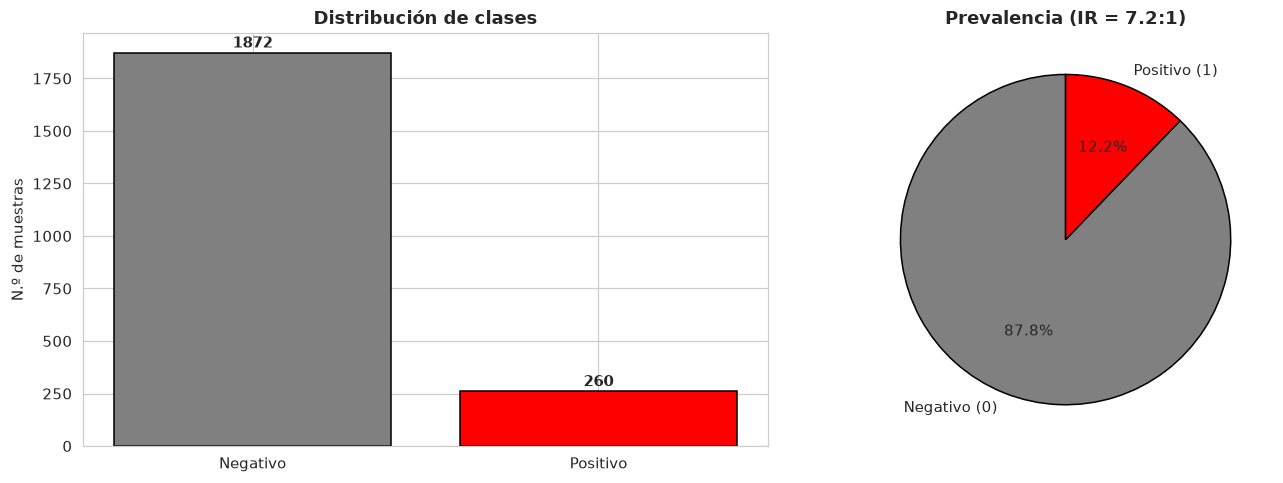

In [6]:
n_neg = int((y_full == 0).sum()); n_pos = int((y_full == 1).sum())
prevalencia = n_pos / (n_pos + n_neg); razon_desb = n_neg / max(n_pos, 1)

print('════════════ DESBALANCE ════════════')
print(f'Negativos: {n_neg:5d}  ({(1-prevalencia)*100:5.2f}%)')
print(f'Positivos: {n_pos:5d}  ({prevalencia*100:5.2f}%)')
print(f'Prevalencia positiva: {prevalencia:.4f}')
print(f'Razón de desbalance (IR): {razon_desb:.2f}:1')
print(f'\nAccuracy engañoso: clasificador trivial "todo negativo" = {(1-prevalencia)*100:.2f}%')
print('Métrica primaria: F1 de la clase positiva; complemento: AUC-PR')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
b = axes[0].bar(['Negativo', 'Positivo'], [n_neg, n_pos], color=['gray', 'red'], edgecolor='black')
for r in b:
    axes[0].text(r.get_x()+r.get_width()/2, r.get_height()+8, f'{int(r.get_height())}',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribución de clases', fontweight='bold')
axes[0].set_ylabel('N.º de muestras')
axes[1].pie([n_neg, n_pos], labels=['Negativo (0)', 'Positivo (1)'], autopct='%1.1f%%',
            colors=['gray', 'red'], startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title(f'Prevalencia (IR = {razon_desb:.1f}:1)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/eda_desbalance.png', bbox_inches='tight'); plt.show()

### Estadística descriptiva

In [11]:
desc_global = df[FEATURES].describe().T
desc_global['skew'] = df[FEATURES].skew()
desc_global['n_nulos'] = df[FEATURES].isna().sum()
desc_global = desc_global.round(3)
desc_global.to_csv(f'{DIR_TAB}/eda_descriptivos_global.csv')
print(f'Guardada en {DIR_TAB}/eda_descriptivos_global.csv')
display(desc_global)

Guardada en outputs_sprint0/tables/eda_descriptivos_global.csv


,count,mean,std,min,25%,50%,75%,max,skew,n_nulos
Ag_ppm,2132.0,7.733,74.889,0.005,0.109,0.301,1.010,2766.906,27.875,0
Al_per,2132.0,5.144,3.026,0.050,2.318,5.515,7.870,15.850,-0.002,0
As_ppm,2132.0,149.825,883.397,0.100,3.678,9.955,31.190,11000.000,10.302,0
Ba_ppm,2132.0,353.289,357.197,5.000,102.952,264.570,512.507,6874.340,4.994,0
Be_ppm,2132.0,0.823,0.519,0.025,0.380,0.740,1.170,3.070,0.704,0
Bi_ppm,2132.0,6.008,107.976,0.005,0.050,0.050,0.160,3566.140,27.645,0
Ca_per,2132.0,2.669,4.558,0.005,0.130,1.260,3.350,35.070,3.918,0
Cd_ppm,2132.0,2.702,34.760,0.010,0.057,0.110,0.230,1100.000,23.212,0
Ce_ppm,2132.0,26.224,18.943,0.005,9.498,24.685,38.320,122.460,0.823,0
Co_ppm,2132.0,10.882,81.716,0.050,1.978,5.335,12.500,2643.080,31.080,0


In [12]:
df_neg = df[df['target_Au'] == 0][FEATURES]
df_pos = df[df['target_Au'] == 1][FEATURES]
comp = pd.DataFrame({
    'media_neg': df_neg.mean(), 'mediana_neg': df_neg.median(),
    'media_pos': df_pos.mean(), 'mediana_pos': df_pos.median(),
}).round(3)
comp['ratio_media'] = (comp['media_pos'] / comp['media_neg'].replace(0, np.nan)).round(2)
comp.to_csv(f'{DIR_TAB}/eda_comparativa_clase.csv')
print(f'Guardada en {DIR_TAB}/eda_comparativa_clase.csv')
display(comp)

Guardada en outputs_sprint0/tables/eda_comparativa_clase.csv


,media_neg,mediana_neg,media_pos,mediana_pos,ratio_media
Ag_ppm,1.181,0.240,54.903,7.136,46.49
Al_per,5.457,6.140,2.889,2.320,0.53
As_ppm,58.517,8.795,807.243,25.180,13.80
Ba_ppm,378.213,305.370,173.842,111.880,0.46
Be_ppm,0.864,0.840,0.522,0.425,0.60
Bi_ppm,1.182,0.050,40.754,0.050,34.48
Ca_per,2.793,1.500,1.777,0.145,0.64
Cd_ppm,1.648,0.100,10.286,0.165,6.24
Ce_ppm,28.206,28.030,11.949,8.595,0.42
Co_ppm,8.548,5.890,27.690,2.280,3.24


### Histogramas

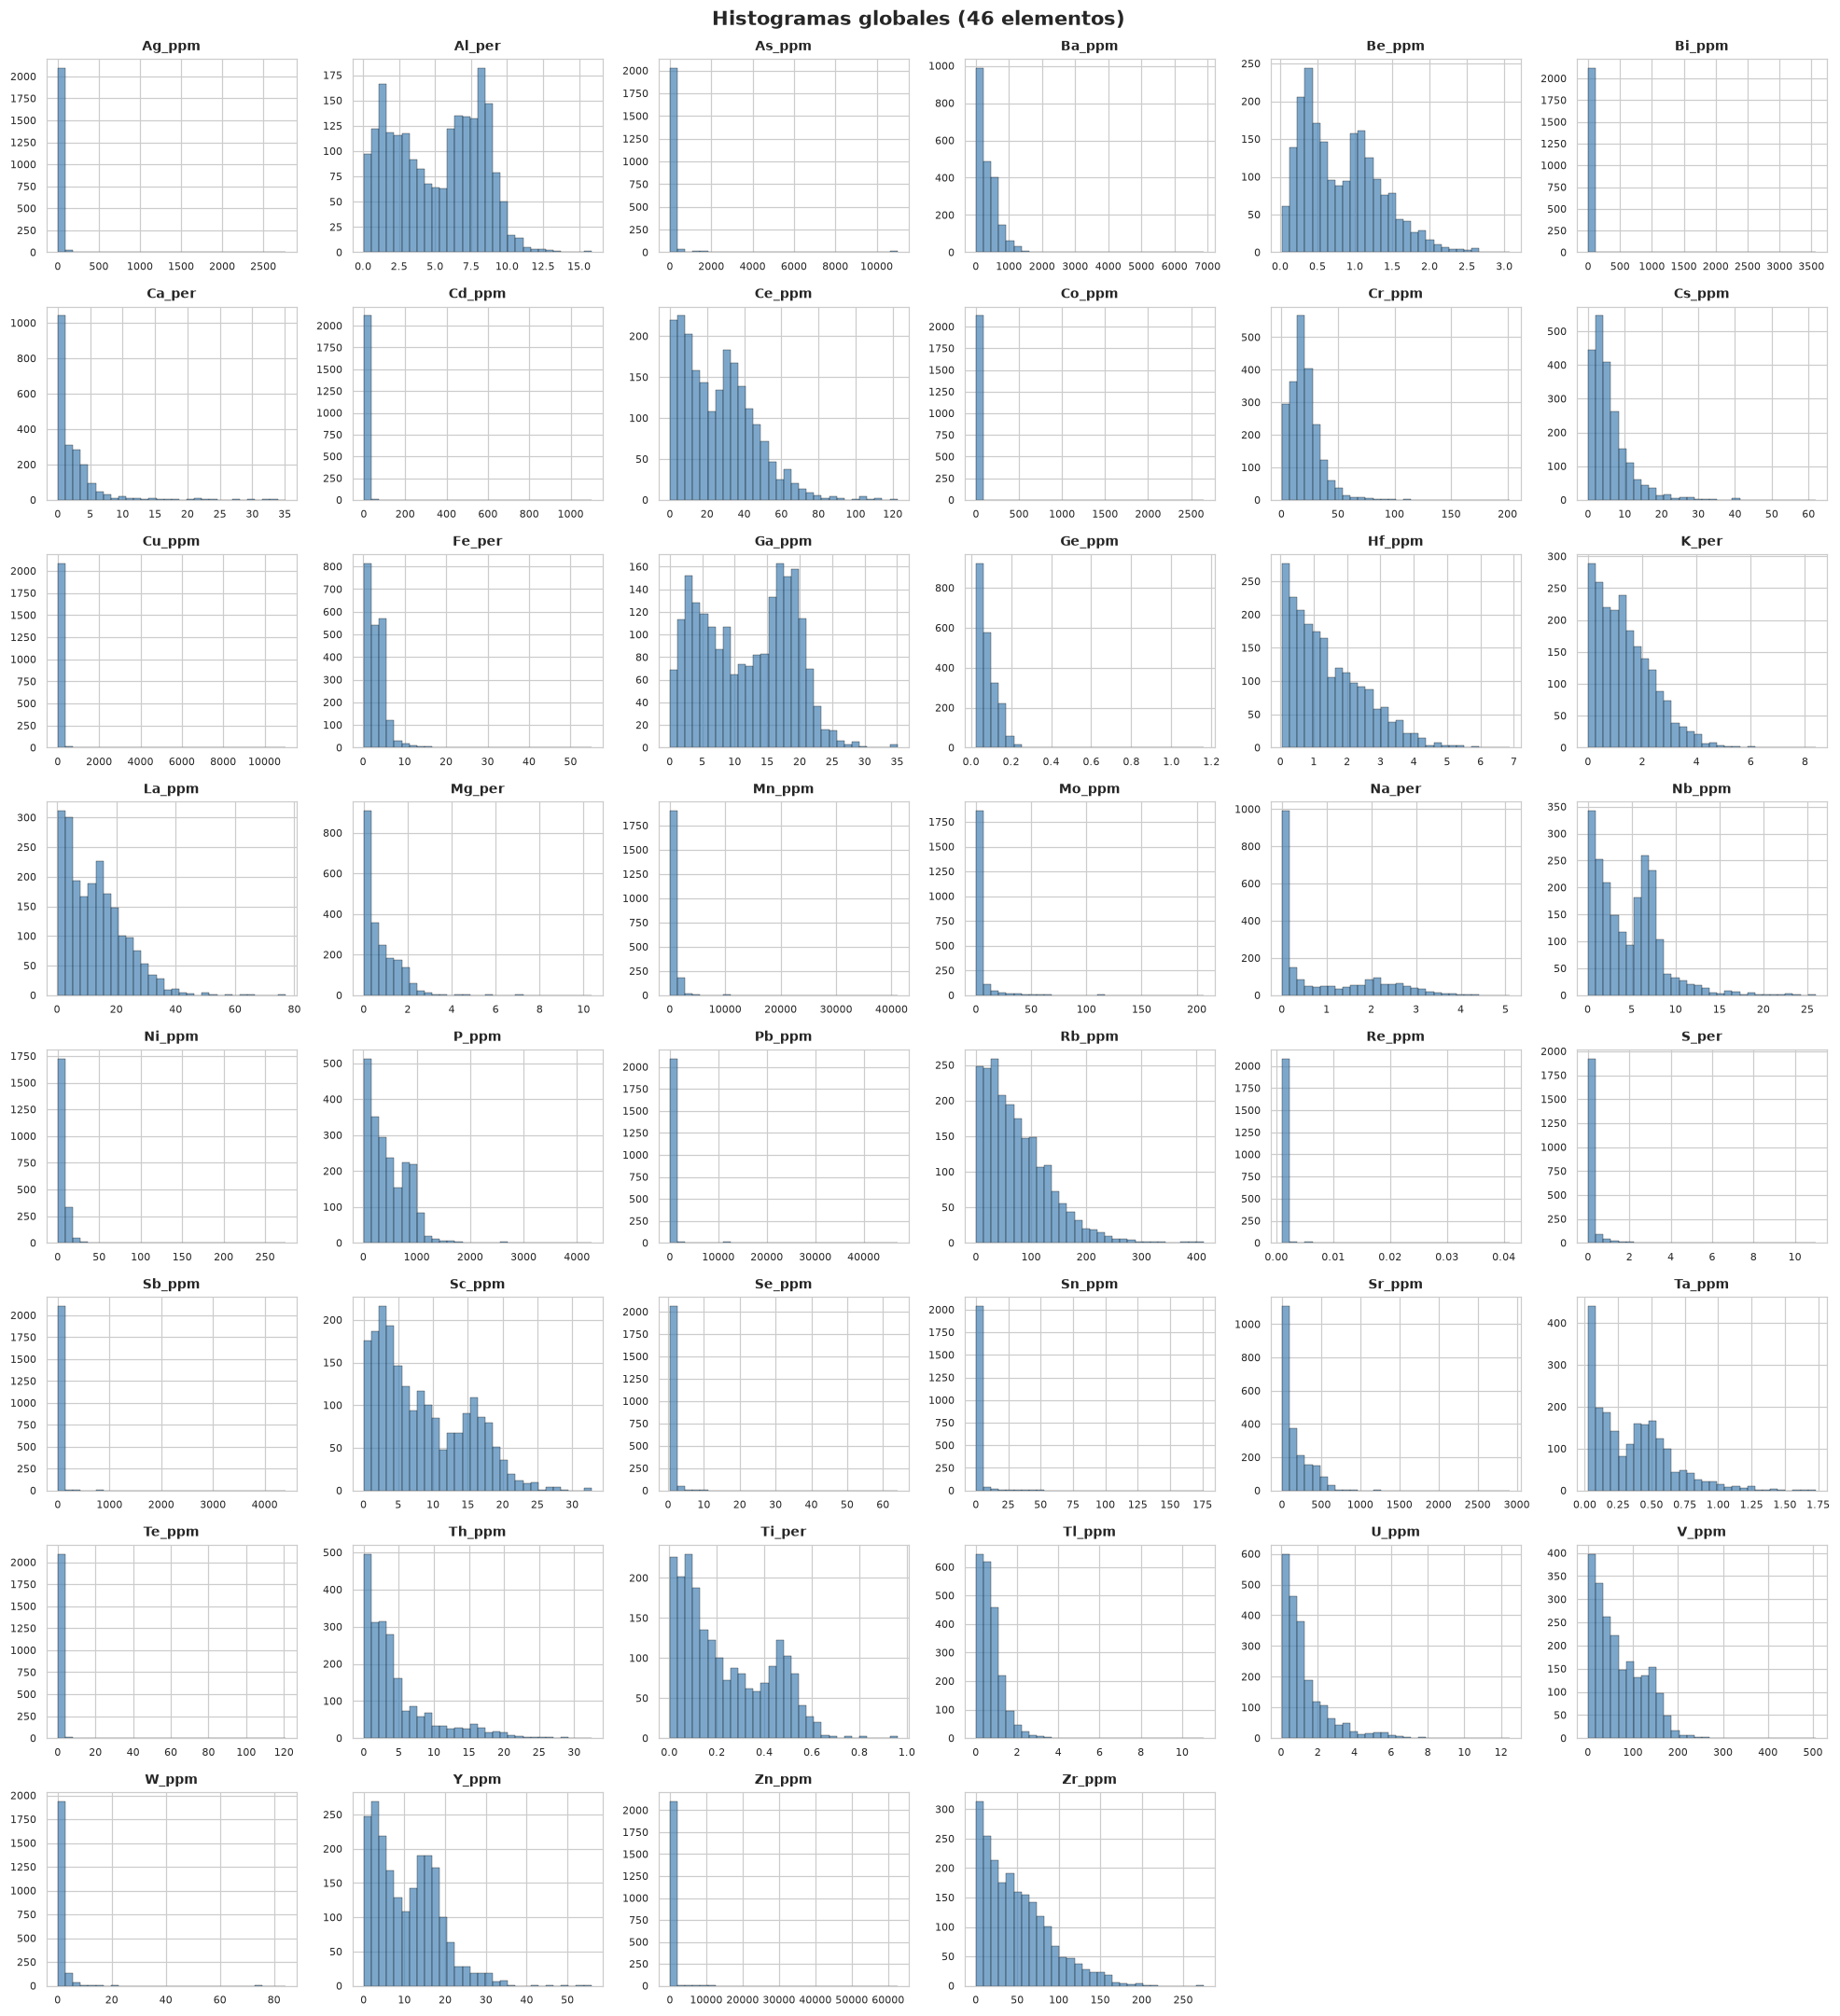

In [17]:
n_feat = len(FEATURES)
ncols = 6; nrows = int(np.ceil(n_feat / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.5))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat].dropna(), bins=30, color='steelblue', edgecolor='black', linewidth=.3, alpha=.7)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Histogramas globales (46 elementos)', fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.savefig(f'{DIR_FIG}/eda_histogramas_global.png', bbox_inches='tight'); plt.show()

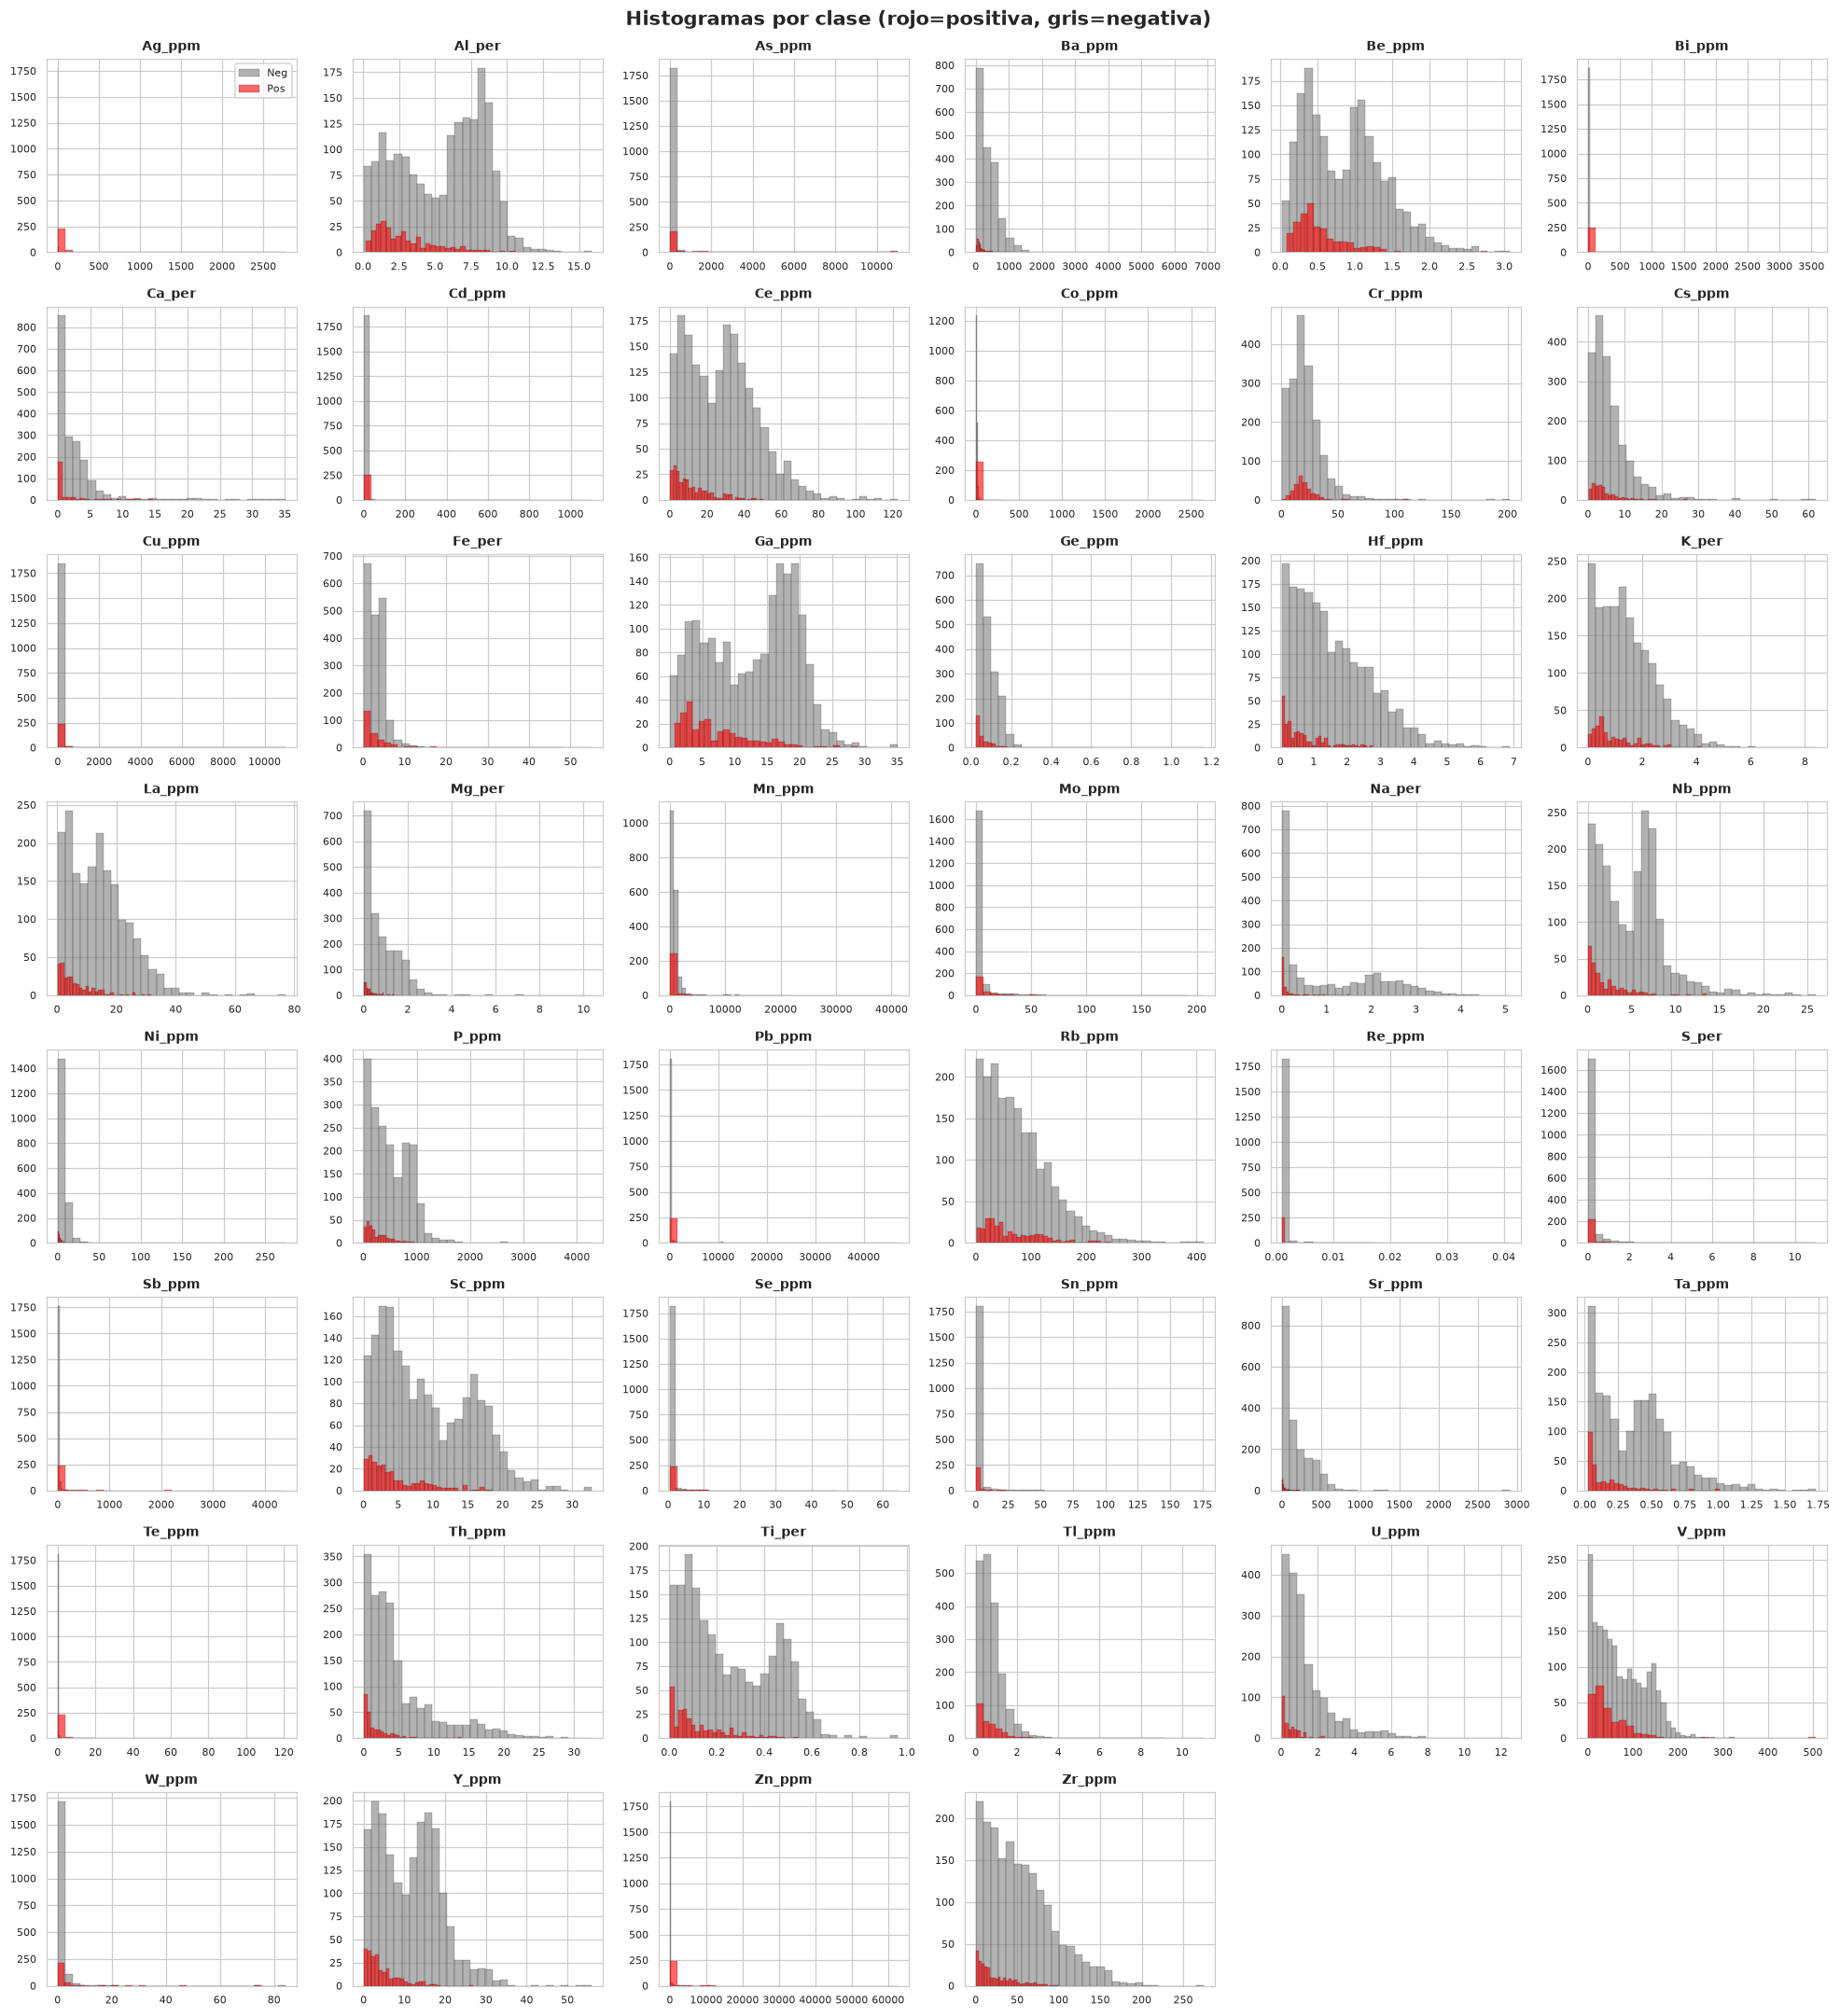

In [19]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.5))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].hist(df_neg[feat].dropna(), bins=30, color='gray', alpha=.6, label='Neg', edgecolor='black', linewidth=.2)
    axes[i].hist(df_pos[feat].dropna(), bins=30, color='red', alpha=.6, label='Pos', edgecolor='black', linewidth=.2)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    if i == 0: axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Histogramas por clase (rojo=positiva, gris=negativa)', fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.savefig(f'{DIR_FIG}/eda_histogramas_clase.png', bbox_inches='tight'); plt.show()

### Boxplots

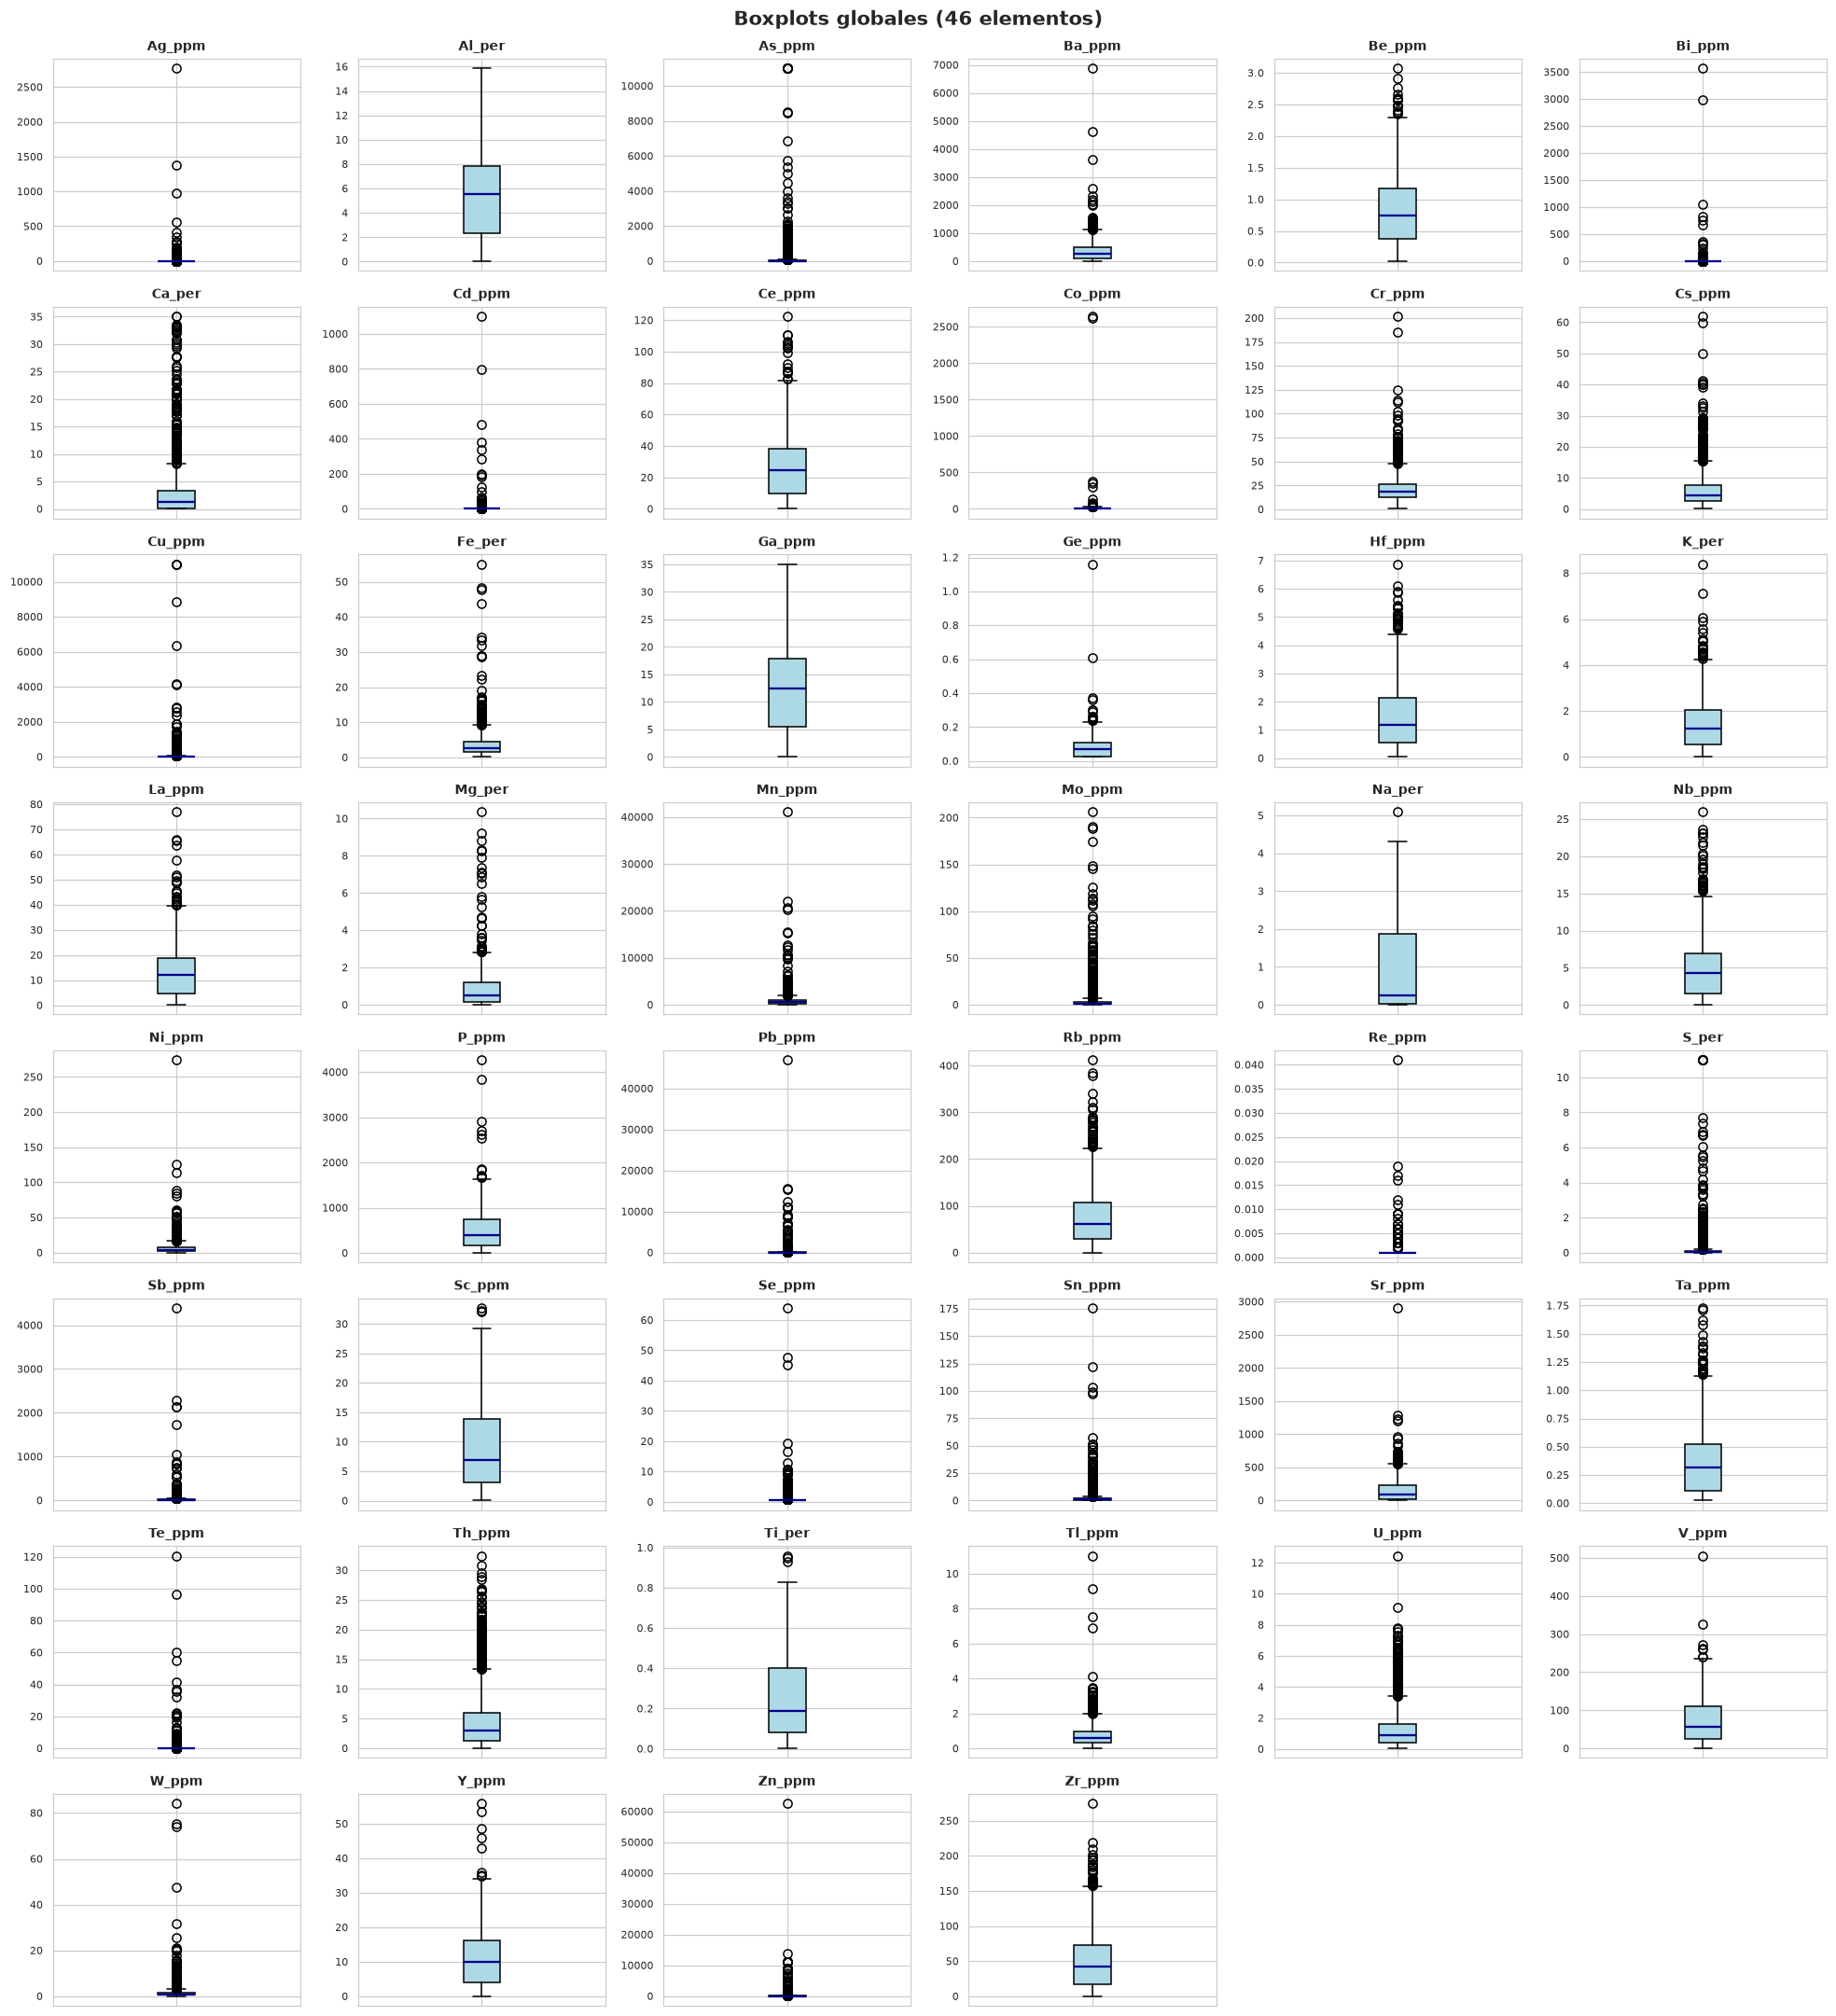

In [20]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.5))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    axes[i].boxplot(df[feat].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', edgecolor='black'),
                    medianprops=dict(color='darkblue', linewidth=1.5))
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7); axes[i].set_xticklabels([''])
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Boxplots globales (46 elementos)', fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.savefig(f'{DIR_FIG}/eda_boxplots_global.png', bbox_inches='tight'); plt.show()

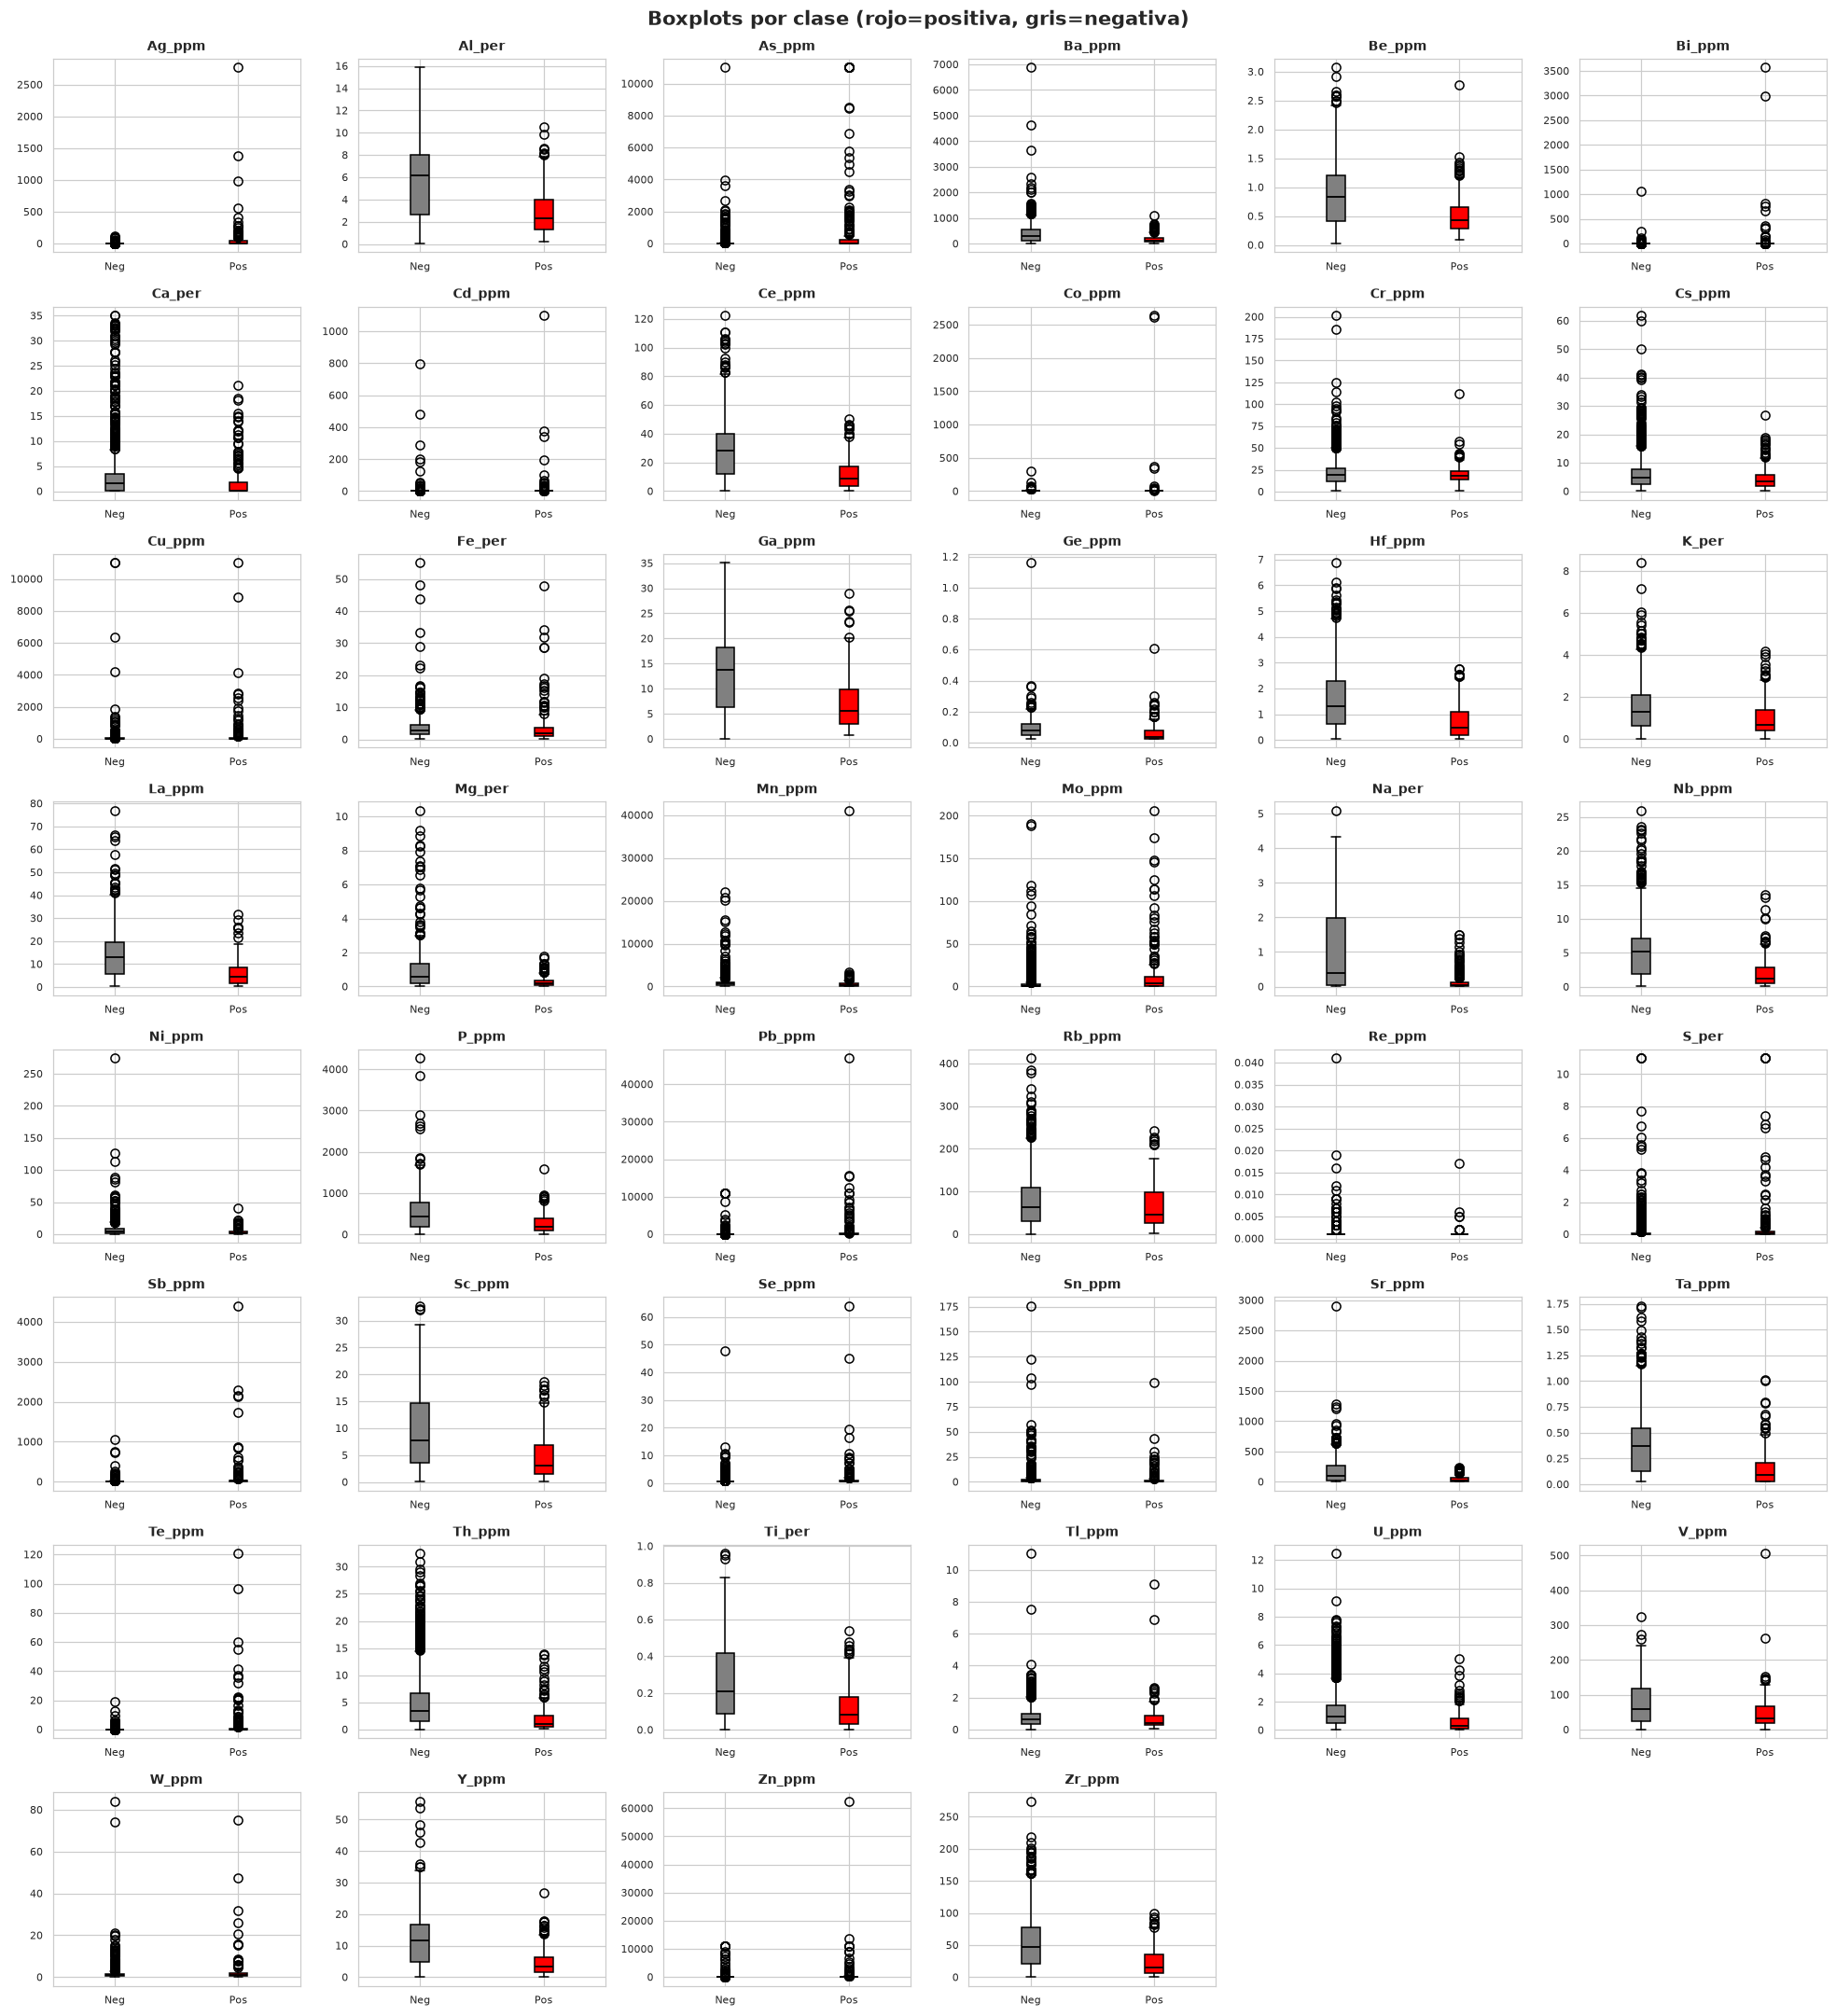

In [22]:
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*2.5))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    data = [df_neg[feat].dropna(), df_pos[feat].dropna()]
    bp = axes[i].boxplot(data, vert=True, patch_artist=True, tick_labels=['Neg', 'Pos'],
                         medianprops=dict(color='black', linewidth=1.2))
    bp['boxes'][0].set_facecolor('gray'); bp['boxes'][1].set_facecolor('red')
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.suptitle('Boxplots por clase (rojo=positiva, gris=negativa)', fontweight='bold', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.99]); plt.savefig(f'{DIR_FIG}/eda_boxplots_clase.png', bbox_inches='tight'); plt.show()

### Matriz de correlación

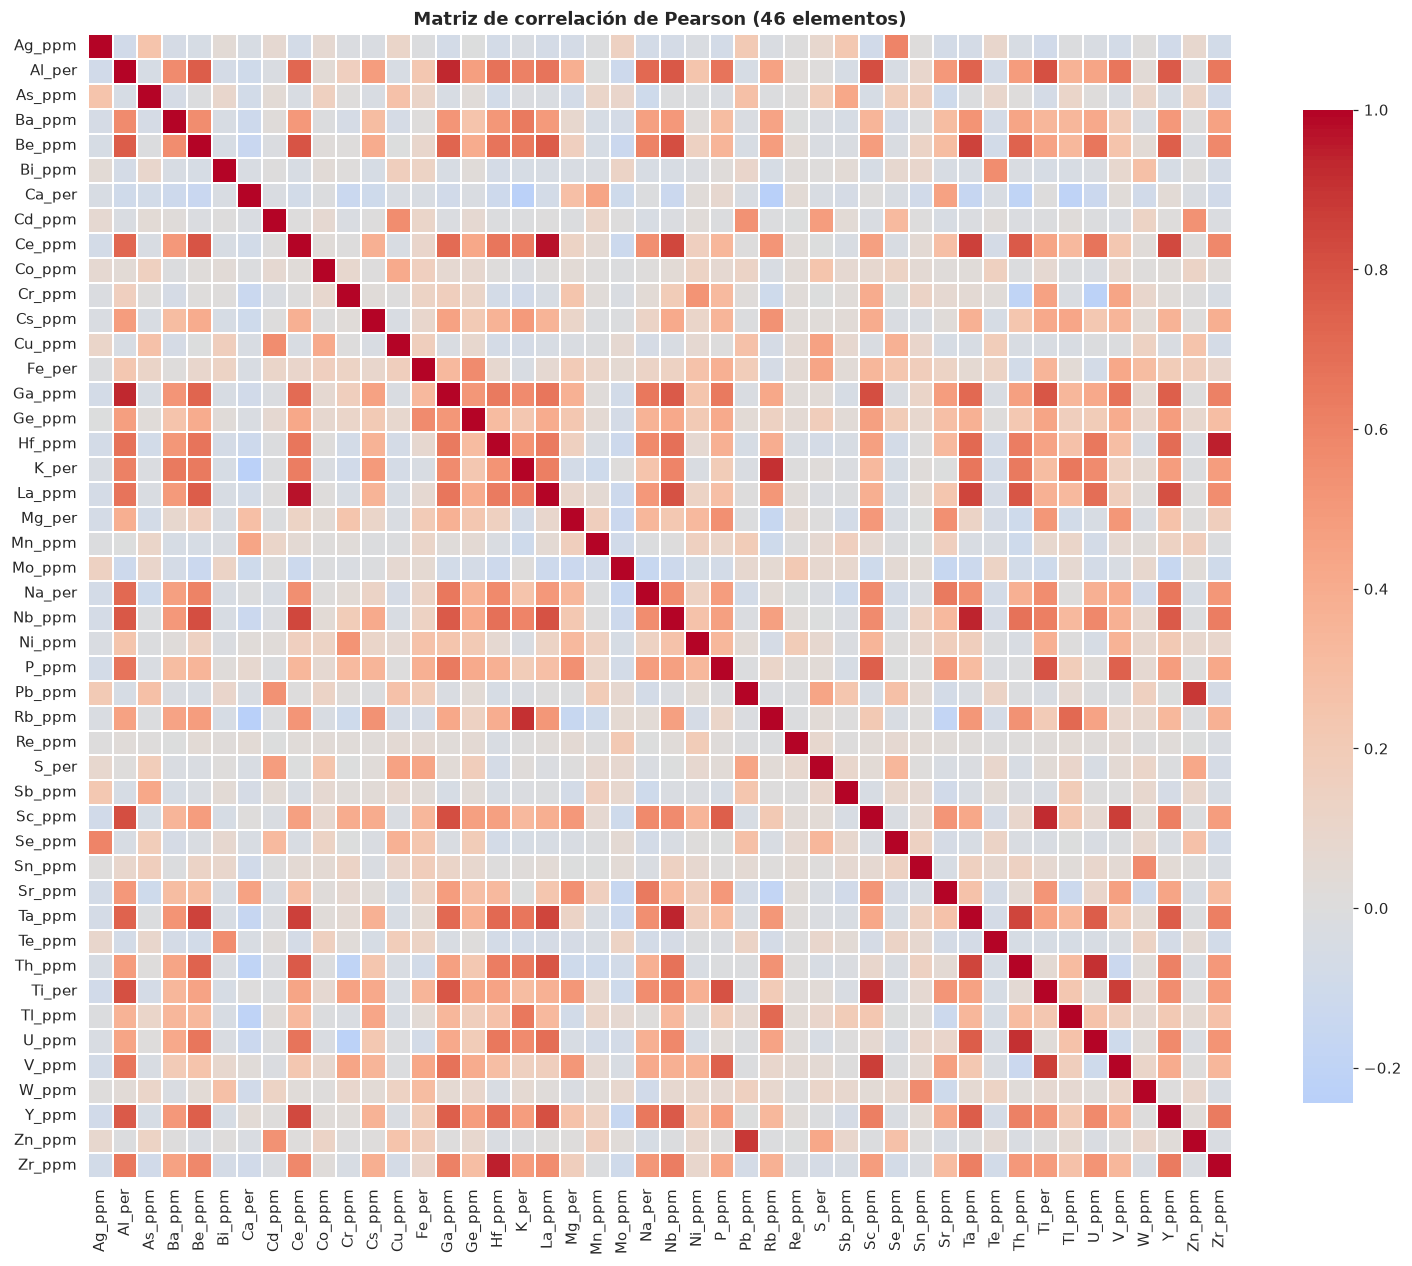

In [23]:
corr_p = df[FEATURES].corr(method='pearson')
corr_p.to_csv(f'{DIR_TAB}/eda_correlacion_pearson.csv')
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_p, cmap='coolwarm', center=0, square=True, linewidths=.3, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Matriz de correlación de Pearson (46 elementos)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/eda_correlacion_pearson.png', bbox_inches='tight'); plt.show()

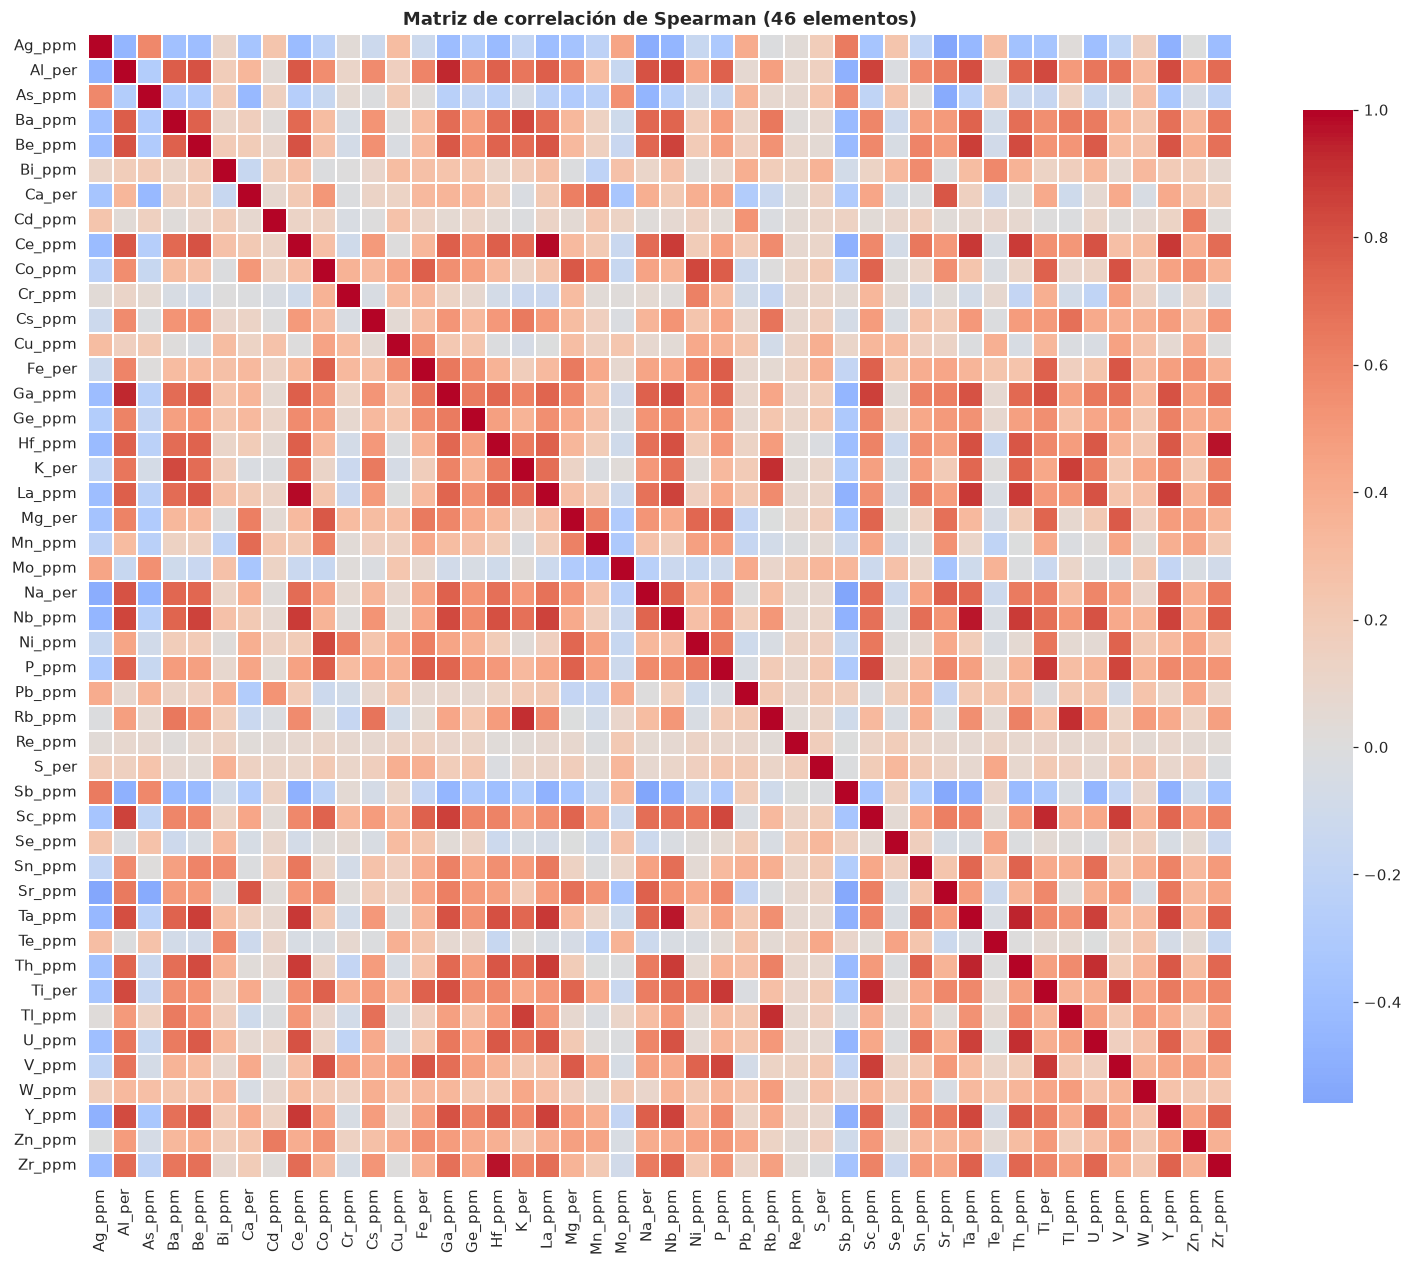

In [24]:
corr_s = df[FEATURES].corr(method='spearman')
corr_s.to_csv(f'{DIR_TAB}/eda_correlacion_spearman.csv')
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_s, cmap='coolwarm', center=0, square=True, linewidths=.3, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Matriz de correlación de Spearman (46 elementos)', fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/eda_correlacion_spearman.png', bbox_inches='tight'); plt.show()

### Mapa de distribución espacial de clases

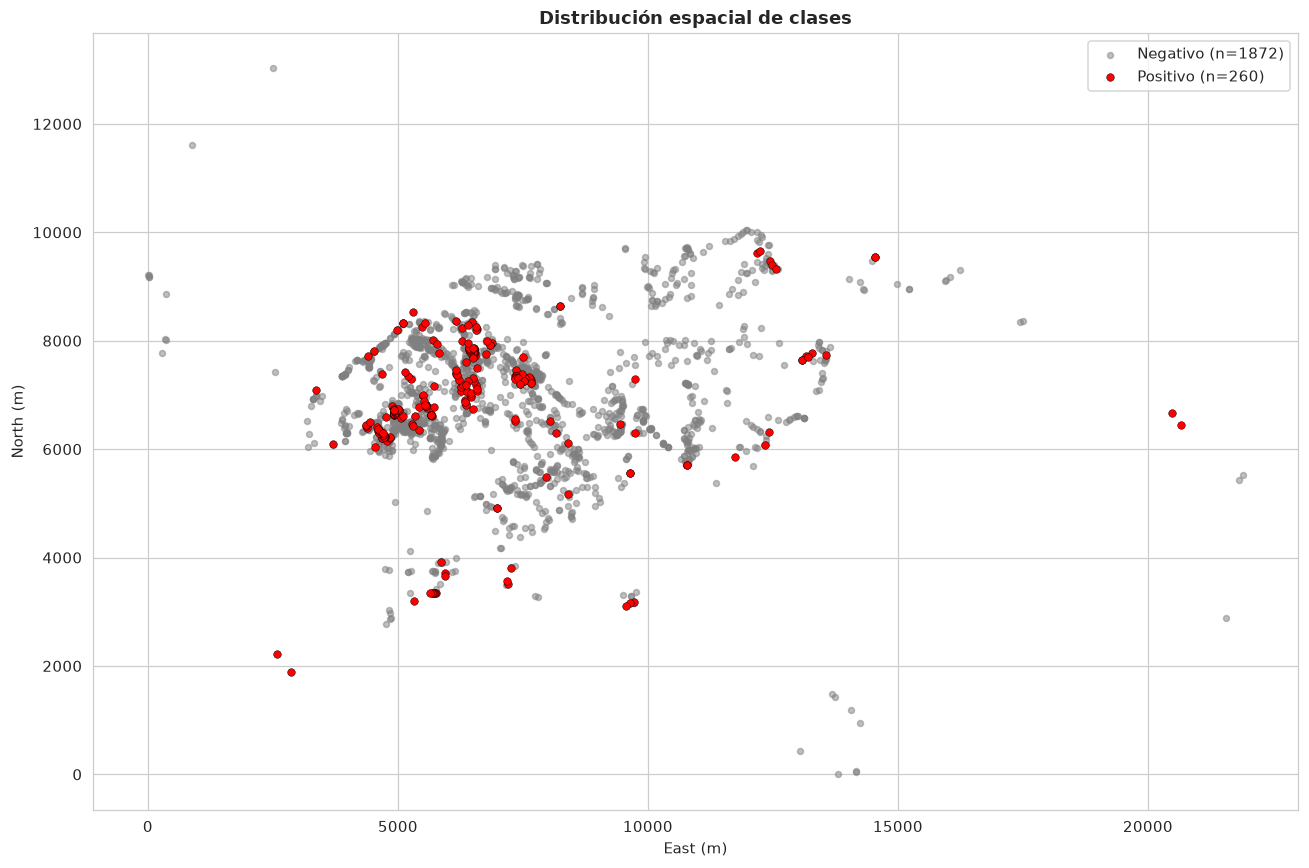

In [25]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(df[df['target_Au']==0]['East'], df[df['target_Au']==0]['North'],
           s=15, c='gray', alpha=.5, label=f'Negativo (n={n_neg})')
ax.scatter(df[df['target_Au']==1]['East'], df[df['target_Au']==1]['North'],
           s=25, c='red', edgecolor='black', linewidth=.3, label=f'Positivo (n={n_pos})')
ax.set_title('Distribución espacial de clases', fontweight='bold')
ax.set_xlabel('East (m)'); ax.set_ylabel('North (m)'); ax.legend()
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/eda_mapa_clases.png', bbox_inches='tight'); plt.show()

## Estrategia de split

**Decisión:** hold-out aleatorio estratificado 80/20 + CV 5-fold estratificada como métrica primaria.

**Justificación:**
- Dataset pequeño-mediano (~2100 muestras) → hold-out único inestable; CV reutiliza todos los datos.
- Desbalance 7:1 → estratificación obligatoria en split y folds.
- 80/20 estándar cuando el conjunto es limitado (~52 positivos en test sin restar mucho al train).

**Split aleatorio (no espacial):** el modelo busca identificar zonas ciegas **dentro** del área ya muestreada (densificación), no extrapolar a terreno nuevo. El ML explota la firma geoquímica
multivariable que se propaga entre vecinos; un split espacial estricto rompería esa señal. A continuación se **cuantifica** la autocorrelación espacial para verificar el supuesto.

In [26]:
X = df[FEATURES].copy()
y = df['target_Au'].astype(int).copy()

X_train, X_test, y_train, y_test, coords_train, coords_test = train_test_split(
    X, y, df[COORDS], test_size=0.20, stratify=y, random_state=SEED)

CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

prev_tr = y_train.mean(); prev_te = y_test.mean()
print('── Verificación de la estratificación ──')
print(f'Dataset completo: {y.mean()*100:.2f}%')
print(f'Train (80%): {prev_tr*100:.2f}%  · n={len(y_train)} · pos={int(y_train.sum())}')
print(f'Test  (20%): {prev_te*100:.2f}%  · n={len(y_test)}  · pos={int(y_test.sum())}')
print(f'Diferencia: {abs(prev_tr-prev_te)*100:.3f} pp (≈0 → bien estratificado)')

── Verificación de la estratificación ──
Dataset completo: 12.20%
Train (80%): 12.20%  · n=1705 · pos=208
Test  (20%): 12.18%  · n=427  · pos=52
Diferencia: 0.021 pp (≈0 → bien estratificado)


── Autocorrelación espacial ──
Test  → vecino de train: media=50.0  mediana=21.8
Train → vecino de train: media=49.0  mediana=19.8

Razón (mediana test/train) = 1.10
Razón ≈1 → test rodeado de train a distancia comparable → densificación intra-área
Split ALEATORIO estratificado es apropiado para el objetivo.


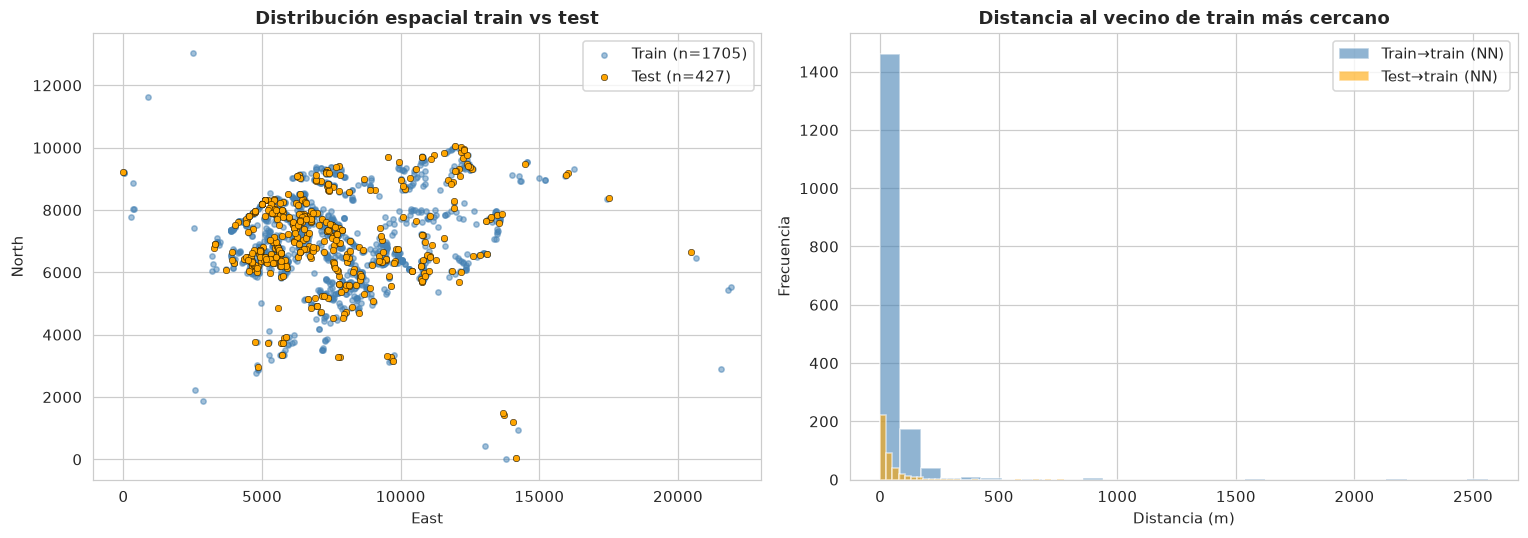

In [27]:
tree_train = cKDTree(coords_train[['East', 'North']].values)
d_test, _ = tree_train.query(coords_test[['East', 'North']].values, k=1)
d_train, _ = tree_train.query(coords_train[['East', 'North']].values, k=2)
d_train_nn = d_train[:, 1]

print('── Autocorrelación espacial ──')
print(f'Test  → vecino de train: media={d_test.mean():.1f}  mediana={np.median(d_test):.1f}')
print(f'Train → vecino de train: media={d_train_nn.mean():.1f}  mediana={np.median(d_train_nn):.1f}')
print(f'\nRazón (mediana test/train) = {np.median(d_test)/np.median(d_train_nn):.2f}')
print('Razón ≈1 → test rodeado de train a distancia comparable → densificación intra-área')
print('Split ALEATORIO estratificado es apropiado para el objetivo.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(coords_train['East'], coords_train['North'], s=12, c='steelblue', alpha=.5,
                label=f'Train (n={len(coords_train)})')
axes[0].scatter(coords_test['East'], coords_test['North'], s=18, c='orange', edgecolor='black',
                linewidth=.3, label=f'Test (n={len(coords_test)})')
axes[0].set_title('Distribución espacial train vs test', fontweight='bold')
axes[0].set_xlabel('East'); axes[0].set_ylabel('North'); axes[0].legend()
axes[1].hist(d_train_nn, bins=30, alpha=.6, color='steelblue', label='Train→train (NN)')
axes[1].hist(d_test, bins=30, alpha=.6, color='orange', label='Test→train (NN)')
axes[1].set_title('Distancia al vecino de train más cercano', fontweight='bold')
axes[1].set_xlabel('Distancia (m)'); axes[1].set_ylabel('Frecuencia'); axes[1].legend()
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/eda_autocorr_espacial.png', bbox_inches='tight'); plt.show()

## Justificación de la métrica principal

Clasificación binaria con desbalance ≈7:1 (12% positivos), clase de interés = positiva (zonas ciegas).

- **Accuracy:** engañosa con desbalance ("todo negativo" = 88% sin detectar nada).
- **AUC-ROC:** puede verse optimista (gran n.º de negativos infla TNR).
- **AUC-PR / Average Precision:** robusta al desbalance, threshold-free, complemento ideal.
- **F1 (clase positiva):** equilibra precision (no malgastar presupuesto de exploración en FP) y recall (no perder zonas prometedoras). Métrica operativa acorde a la decisión de "marcar zona".

**Decisión:** F1 como primaria (por CV 5-fold estratificada); AUC-PR, AUC-ROC, precision, recall y accuracy como complementarias.

## Baseline

Configuración por defecto/ligera con respaldo bibliográfico. Sin balanceo (Sprint 0 = baseline puro).

| Modelo | Hiperparámetros | Ref. Teórica | Ref. Geociencias |
|---|---|---|---|
| KNN | `n_neighbors=5` | Hastie et al. (2009), Elements of Statistical Learning | Abedi et al. (2012), Comp. Geosci. — mapeo de prospectividad Au |
| Reg. Logística | `max_iter=1000`, L2 | Bishop (2006), *Pattern Recognition and ML* | Carranza (2008), Math. Geosci. — predicción de depósitos minerales |
| SVM (RBF) | `kernel='rbf'`, `gamma='scale'` | Cortes & Vapnik (1995), *Support-Vector Networks* | Zuo & Carranza (2011), Comp. Geosci. — prospectividad geoquímica |
| MLP | `hidden=(100,)`, `max_iter=500` | Goodfellow et al. (2016), *Deep Learning* | Porwal et al. (2015), Ore Geol. Rev. — mapeo predictivo mineral |
| Árbol de decisión | por defecto | Breiman et al. (1984), *CART* | Harris et al. (2015), Nat. Res. Res. — exploración geoquímica |
| Random Forest | `n_estimators=100` | Breiman (2001), *Random Forests* | Carranza & Laborte (2015), Geosci. Front. — prospectividad Au-Cu |
| ExtraTrees | `n_estimators=100` | Geurts et al. (2006), *Extremely Randomized Trees* | Rodriguez-Galiano et al. (2015), Comp. Geosci. — modelado geológico |
| HistGradientBoosting | por defecto | Ke et al. (2017), *LightGBM*, NeurIPS | Chen et al. (2019), Nat. Res. Res. — predicción de mineralización |
| XGBoost | `n_estimators=100`, `tree_method='hist'` | Chen & Guestrin (2016), *XGBoost*, KDD | Sun et al. (2020), Ore Geol. Rev. — prospectividad geoquímica Au |
| LightGBM | `n_estimators=100` | Ke et al. (2017), NeurIPS | Li et al. (2021), Minerals — clasificación de anomalías geoquímicas |
| CatBoost | `iterations=100` | Prokhorenkova et al. (2018), *CatBoost*, NeurIPS | Zuo et al. (2022), Math. Geosci. — mapeo de prospectividad con ML |

Pipeline con `StandardScaler` (necesario para KNN/LogReg/SVM/MLP, inofensivo para árboles).

In [29]:
def crear_modelos():
    '''11 modelos baseline. Pipeline con StandardScaler, sin balanceo.'''
    return {
        'KNN': Pipeline([('sc', StandardScaler()),
                         ('clf', KNeighborsClassifier(n_neighbors=5))]),
        'Reg. Logística': Pipeline([('sc', StandardScaler()),
                                     ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
        'SVM (RBF)': Pipeline([('sc', StandardScaler()),
                                ('clf', SVC(kernel='rbf', probability=True, random_state=SEED))]),
        'MLP': Pipeline([('sc', StandardScaler()),
                         ('clf', MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=SEED))]),
        'Árbol de Decisión': Pipeline([('sc', StandardScaler()),
                                        ('clf', DecisionTreeClassifier(random_state=SEED))]),
        'Random Forest': Pipeline([('sc', StandardScaler()),
                                    ('clf', RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1))]),
        'ExtraTrees': Pipeline([('sc', StandardScaler()),
                                 ('clf', ExtraTreesClassifier(n_estimators=100, random_state=SEED, n_jobs=-1))]),
        'HistGradientBoosting': Pipeline([('sc', StandardScaler()),
                                           ('clf', HistGradientBoostingClassifier(random_state=SEED))]),
        'XGBoost': Pipeline([('sc', StandardScaler()),
                             ('clf', xgb.XGBClassifier(n_estimators=100, random_state=SEED,
                                                       eval_metric='logloss', tree_method='hist', n_jobs=-1))]),
        'LightGBM': Pipeline([('sc', StandardScaler()),
                              ('clf', lgb.LGBMClassifier(n_estimators=100, random_state=SEED, verbose=-1, n_jobs=-1))]),
        'CatBoost': Pipeline([('sc', StandardScaler()),
                              ('clf', CatBoostClassifier(iterations=100, random_seed=SEED, verbose=0,
                                                         allow_writing_files=False))]),
    }

def scores_pos(modelo, Xte):
    clf = modelo.named_steps['clf'] if hasattr(modelo, 'named_steps') else modelo
    if hasattr(clf, 'predict_proba'):
        return modelo.predict_proba(Xte)[:, 1]
    return modelo.decision_function(Xte)

def f1_cv(modelo):
    '''F1 por CV 5-fold estratificada (MÉTRICA PRIMARIA).'''
    sc = cross_val_score(modelo, X_train, y_train, cv=CV5, scoring='f1', n_jobs=-1)
    return sc.mean(), sc.std()

def metricas_holdout(yte, y_pred, y_sco):
    return {
        'F1': f1_score(yte, y_pred), 'Accuracy': accuracy_score(yte, y_pred),
        'Precision': precision_score(yte, y_pred, zero_division=0), 'Recall': recall_score(yte, y_pred),
        'AUC-ROC': roc_auc_score(yte, y_sco), 'AUC-PR': average_precision_score(yte, y_sco),
    }

def resaltar_maximo(s):
    estilos = [''] * len(s)
    estilos[s.index.get_loc(s.idxmax())] = 'background-color: coral; color: white; font-weight: bold'
    return estilos

print('Funciones listas')

Funciones listas


In [30]:
import time
f1_cv_mean, f1_cv_std, tiempos = {}, {}, {}
for n, m in crear_modelos().items():
    t0 = time.time()
    mu, sd = f1_cv(m)
    f1_cv_mean[n], f1_cv_std[n] = mu, sd
    tiempos[n] = time.time() - t0
    print(f'  {n}: F1_CV={mu:.4f} ± {sd:.4f} ({tiempos[n]:.1f}s)')

tabla_cv = pd.DataFrame({
    'F1_CV (media)': pd.Series(f1_cv_mean),
    'F1_CV (std)': pd.Series(f1_cv_std),
    'Tiempo (s)': pd.Series(tiempos),
}).loc[MODELOS].round(4)
tabla_cv.to_csv(f'{DIR_TAB}/baseline_f1_cv.csv')

mejor_modelo = tabla_cv['F1_CV (media)'].idxmax()
print(f'\n★ GANADOR por F1_CV: {mejor_modelo} '
      f'(F1_CV = {tabla_cv.loc[mejor_modelo, "F1_CV (media)"]:.4f} ± '
      f'{tabla_cv.loc[mejor_modelo, "F1_CV (std)"]:.4f})')
tabla_cv.style.apply(resaltar_maximo, axis=0, subset=['F1_CV (media)'])\
        .format('{:.4f}', subset=['F1_CV (media)', 'F1_CV (std)'])\
        .format('{:.1f}', subset=['Tiempo (s)'])

  KNN: F1_CV=0.4357 ± 0.0857 (9.7s)
  Reg. Logística: F1_CV=0.5493 ± 0.0939 (0.1s)
  SVM (RBF): F1_CV=0.1895 ± 0.0330 (0.9s)
  MLP: F1_CV=0.6413 ± 0.0524 (10.0s)
  Árbol de Decisión: F1_CV=0.5448 ± 0.0426 (0.2s)
  Random Forest: F1_CV=0.6501 ± 0.0306 (1.9s)
  ExtraTrees: F1_CV=0.5881 ± 0.0871 (1.5s)
  HistGradientBoosting: F1_CV=0.7034 ± 0.0352 (2.3s)
  XGBoost: F1_CV=0.7090 ± 0.0322 (2.1s)
  LightGBM: F1_CV=0.6937 ± 0.0507 (9.0s)
  CatBoost: F1_CV=0.6671 ± 0.0310 (5.6s)

★ GANADOR por F1_CV: XGBoost (F1_CV = 0.7090 ± 0.0322)


,F1_CV (media),F1_CV (std),Tiempo (s)
KNN,0.4357,0.0857,9.7
Reg. Logística,0.5493,0.0939,0.1
SVM (RBF),0.1895,0.0330,0.9
MLP,0.6413,0.0524,10.0
Árbol de Decisión,0.5448,0.0426,0.2
Random Forest,0.6501,0.0306,1.9
ExtraTrees,0.5881,0.0871,1.5
HistGradientBoosting,0.7034,0.0352,2.3
XGBoost,0.7090,0.0322,2.1
LightGBM,0.6937,0.0507,9.0


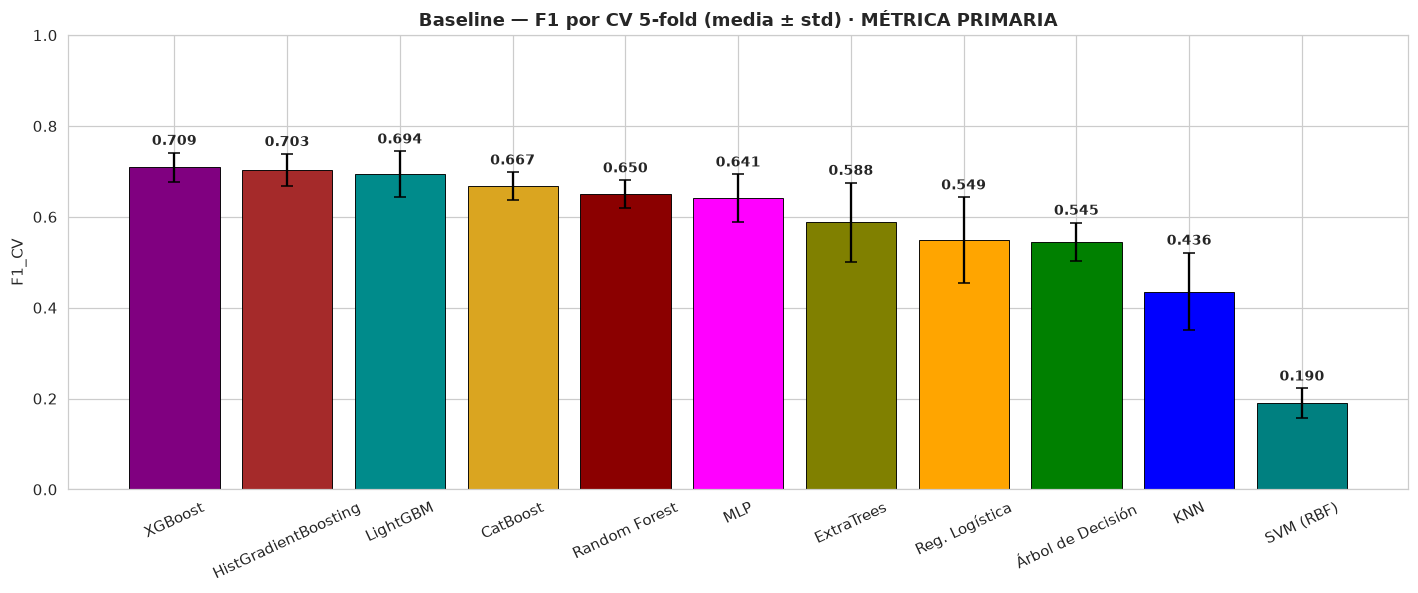

In [31]:
orden = tabla_cv['F1_CV (media)'].sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(13, 5.5))
b = ax.bar(orden, tabla_cv.loc[orden, 'F1_CV (media)'], yerr=tabla_cv.loc[orden, 'F1_CV (std)'],
           color=[MODEL_COLORS[m] for m in orden], edgecolor='black', linewidth=.6, capsize=4)
ax.set_title('Baseline — F1 por CV 5-fold (media ± std) · MÉTRICA PRIMARIA', fontweight='bold')
ax.set_ylabel('F1_CV'); ax.set_ylim(0, 1); ax.tick_params(axis='x', rotation=25)
for r, m in zip(b, orden):
    ax.text(r.get_x()+r.get_width()/2, r.get_height()+tabla_cv.loc[m, 'F1_CV (std)']+.01,
            f'{r.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/baseline_f1_cv_barras.png', bbox_inches='tight'); plt.show()

In [32]:
modelos_guardados = {}
modelos_fit = {}
for n, m in crear_modelos().items():
    m.fit(X_train, y_train)
    modelos_fit[n] = m
    fname = 'modelo_' + (n.replace(' ', '_').replace('(', '').replace(')', '')
                          .replace('.', '').replace('á', 'a').replace('é', 'e')
                          .replace('í', 'i').replace('ó', 'o')) + '.pkl'
    ruta = f'{DIR_MODELS}/{fname}'
    joblib.dump(m, ruta)
    modelos_guardados[n] = ruta
print(f'{len(modelos_guardados)} modelos guardados en {DIR_MODELS}/')

11 modelos guardados en outputs_sprint0/models/


In [33]:
METRICAS = ['F1', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC', 'AUC-PR']
res_ho = {}
for n, m in modelos_fit.items():
    y_pred = m.predict(X_test); y_sco = scores_pos(m, X_test)
    d = metricas_holdout(y_test, y_pred, y_sco)
    d['_pred'] = y_pred; d['_score'] = y_sco
    res_ho[n] = d

tabla_ho = pd.DataFrame({m: {k: res_ho[m][k] for k in METRICAS} for m in MODELOS}).T[METRICAS].round(4)
tabla_ho.to_csv(f'{DIR_TAB}/baseline_holdout_metricas.csv')
print('Métricas en hold-out (informativas — NO deciden)')
tabla_ho.style.apply(resaltar_maximo, axis=0, subset=METRICAS).format('{:.4f}', subset=METRICAS)

Métricas en hold-out (informativas — NO deciden)


,F1,Accuracy,Precision,Recall,AUC-ROC,AUC-PR
KNN,0.3243,0.8829,0.5455,0.2308,0.8390,0.4031
Reg. Logística,0.6118,0.9227,0.7879,0.5000,0.9369,0.7451
SVM (RBF),0.2333,0.8923,0.8750,0.1346,0.9122,0.6388
MLP,0.7551,0.9438,0.8043,0.7115,0.9395,0.7869
Árbol de Decisión,0.6393,0.8970,0.5571,0.7500,0.8337,0.4483
Random Forest,0.6437,0.9274,0.8000,0.5385,0.9547,0.7824
ExtraTrees,0.5750,0.9204,0.8214,0.4423,0.9469,0.7601
HistGradientBoosting,0.7447,0.9438,0.8333,0.6731,0.9674,0.8519
XGBoost,0.7629,0.9461,0.8222,0.7115,0.9648,0.8630
LightGBM,0.7216,0.9368,0.7778,0.6731,0.9668,0.8506


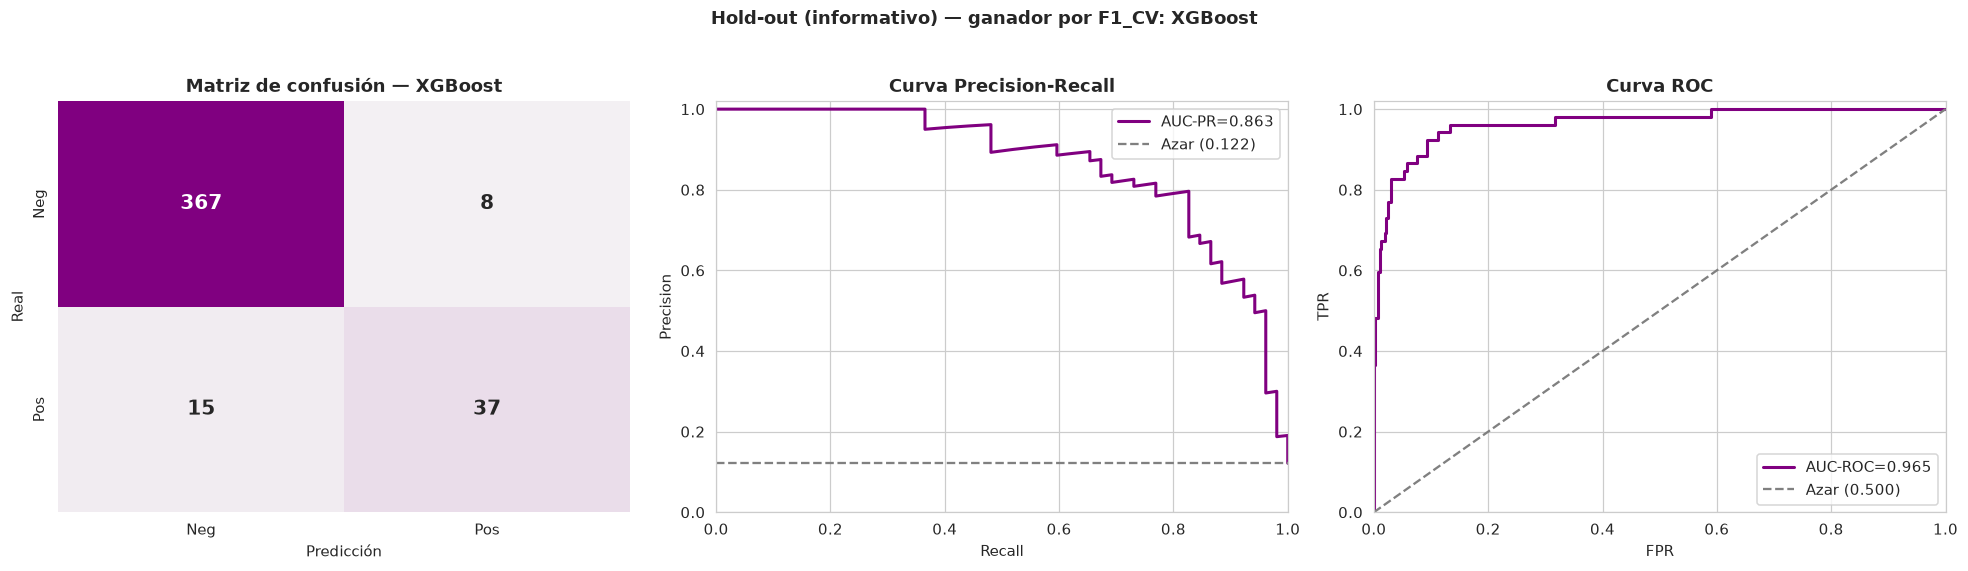

In [34]:
rm = res_ho[mejor_modelo]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, rm['_pred'])
sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=axes[0],
            cmap=sns.light_palette(MODEL_COLORS[mejor_modelo], as_cmap=True),
            xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
            annot_kws={'size': 13, 'fontweight': 'bold'})
axes[0].set_title(f'Matriz de confusión — {mejor_modelo}', fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

p, r, _ = precision_recall_curve(y_test, rm['_score'])
axes[1].plot(r, p, color=MODEL_COLORS[mejor_modelo], lw=2, label=f'AUC-PR={rm["AUC-PR"]:.3f}')
axes[1].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva Precision-Recall', fontweight='bold'); axes[1].legend()

fpr, tpr, _ = roc_curve(y_test, rm['_score'])
axes[2].plot(fpr, tpr, color=MODEL_COLORS[mejor_modelo], lw=2, label=f'AUC-ROC={rm["AUC-ROC"]:.3f}')
axes[2].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1.02)
axes[2].set_title('Curva ROC', fontweight='bold'); axes[2].legend(loc='lower right')
plt.suptitle(f'Hold-out (informativo) — ganador por F1_CV: {mejor_modelo}', fontweight='bold', y=1.03)
plt.tight_layout(); plt.savefig(f'{DIR_FIG}/baseline_ganador_curvas.png', bbox_inches='tight'); plt.show()

## Resumen

In [35]:
f1_cv_final = round(float(tabla_cv.loc[mejor_modelo, 'F1_CV (media)']), 4)
f1_cv_std_final = round(float(tabla_cv.loc[mejor_modelo, 'F1_CV (std)']), 4)

resumen0 = {
    'sprint': 0,
    'nombre': 'Baseline + ingesta/preprocesamiento + EDA',
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'dataset': {
        'n_muestras': int(df.shape[0]), 'n_features': len(FEATURES),
        'prevalencia_pos': round(prevalencia, 4), 'razon_desbalance': round(razon_desb, 2),
        'umbral_target_Au_ppm': UMBRAL_AU, 'ruta_data_procesada': RUTA_PROC,
    },
    'split': {'estrategia': 'aleatorio estratificado', 'test_size': 0.20, 'seed': SEED,
              'prevalencia_train': round(float(prev_tr), 4), 'prevalencia_test': round(float(prev_te), 4)},
    'protocolo_cv': {'tipo': 'StratifiedKFold', 'n_splits': 5, 'shuffle': True, 'seed': SEED},
    'metrica_primaria': 'f1',
    'metricas_complementarias': ['AUC-PR', 'AUC-ROC', 'Precision', 'Recall', 'Accuracy'],
    'balanceo': None,
    'mejor_modelo': mejor_modelo,
    'f1_cv_media': f1_cv_final,
    'f1_cv_std': f1_cv_std_final,
    'f1_final': f1_cv_final,
    'metricas_holdout_informativo': {m: round(float(res_ho[mejor_modelo][m]), 4) for m in METRICAS},
    'f1_cv_por_modelo': {m: round(float(f1_cv_mean[m]), 4) for m in MODELOS},
    'f1_std_por_modelo': {m: round(float(f1_cv_std[m]), 4) for m in MODELOS},
    'modelos_guardados': modelos_guardados,
    'versiones_librerias': versiones,
    'rutas': {'data': DIR_DATA, 'models': DIR_MODELS, 'figures': DIR_FIG, 'tables': DIR_TAB},
}
with open(f'{OUT}/resumen_sprint0.json', 'w') as f:
    json.dump(resumen0, f, indent=2, ensure_ascii=False)

print('════════════════════ RESUMEN SPRINT 0 ════════════════════')
print(f'Dataset: {df.shape[0]} muestras · {len(FEATURES)} features · IR={razon_desb:.1f}:1 · prev={prevalencia*100:.2f}%')
print(f'Split  : aleatorio estratificado 80/20 (SEED={SEED}) — hold-out solo informativo')
print(f'Métrica primaria: F1 (clase positiva) por CV 5-fold estratificada')
print('\nRanking baseline por F1_CV:')
rank = tabla_cv['F1_CV (media)'].sort_values(ascending=False)
for i, (mod, f1v) in enumerate(rank.items(), 1):
    marca = ' ← GANADOR' if mod == mejor_modelo else ''
    print(f'  {i:2d}. {mod:22s} F1_CV = {f1v:.4f} ± {tabla_cv.loc[mod, "F1_CV (std)"]:.4f}{marca}')
print(f'\nMejor baseline: {mejor_modelo}')
print(f'   F1_CV       = {f1_cv_final:.4f} ± {f1_cv_std_final:.4f}   (decisión)')
print(f'   F1 hold-out = {res_ho[mejor_modelo]["F1"]:.4f}   (informativo)')
print(f'\n{len(modelos_guardados)} modelos persistidos en {DIR_MODELS}/')
print('Resumen unificado: outputs_sprint0/resumen_sprint0.json')
print('\nSiguiente (Sprint 1): balanceo DENTRO de cada fold + PCA, decidiendo por F1_CV.')

════════════════════ RESUMEN SPRINT 0 ════════════════════
Dataset: 2132 muestras · 46 features · IR=7.2:1 · prev=12.20%
Split  : aleatorio estratificado 80/20 (SEED=42) — hold-out solo informativo
Métrica primaria: F1 (clase positiva) por CV 5-fold estratificada

Ranking baseline por F1_CV:
   1. XGBoost                F1_CV = 0.7090 ± 0.0322 ← GANADOR
   2. HistGradientBoosting   F1_CV = 0.7034 ± 0.0352
   3. LightGBM               F1_CV = 0.6937 ± 0.0507
   4. CatBoost               F1_CV = 0.6671 ± 0.0310
   5. Random Forest          F1_CV = 0.6501 ± 0.0306
   6. MLP                    F1_CV = 0.6413 ± 0.0524
   7. ExtraTrees             F1_CV = 0.5881 ± 0.0871
   8. Reg. Logística         F1_CV = 0.5493 ± 0.0939
   9. Árbol de Decisión      F1_CV = 0.5448 ± 0.0426
  10. KNN                    F1_CV = 0.4357 ± 0.0857
  11. SVM (RBF)              F1_CV = 0.1895 ± 0.0330

Mejor baseline: XGBoost
   F1_CV       = 0.7090 ± 0.0322   (decisión)
   F1 hold-out = 0.7629   (informativo)

11